DSCI 552 Homework 4

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

HOMEWORK 3 PORTION NEEDED FOR HOMEWORK 4:

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay, accuracy_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.feature_selection import RFE

from imblearn.under_sampling import RandomUnderSampler

from itertools import combinations
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path
import re

In [2]:
# I manually edited bending2 dataset4 to have the delimiter be "," since it was causing issues
path_to_AReM = Path("../data/AReM")
column_names = ["time", "avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]

training_dfs = {}
testing_dfs = {}

for data_dir in path_to_AReM.iterdir():
    if data_dir.is_dir(): # want to skip the .pdfs
        dir_name = data_dir.name
            
        for file in data_dir.iterdir():
            if not file.is_file():
                continue
                # added this becasue for some reason it was reading .ipynb_checkpoints folder (idk how or why)
            
            file_name = Path(file).stem
            file_num = int("".join(re.findall(r"\d", file_name)))

            key = f"{dir_name}_{file_name}"
            
            if (dir_name == "bending1") or (dir_name == "bending2"):
                df = pd.read_csv(file, skiprows=5, names=column_names)
                
                if (file_num == 1) or (file_num == 2):
                    testing_dfs[key] = df
                else:
                    training_dfs[key] = df
            else: 
                df = pd.read_csv(file, skiprows=5, names=column_names)
                
                if (file_num == 1) or (file_num == 2) or (file_num == 3):
                    testing_dfs[key] = df
                else:
                    training_dfs[key] = df

In [3]:
columns_six = column_names[1:]

training_features = []
# 69 rows x 42 columns
# looks like:
    # [ {dirfilename : name, min1 : x, max1 : x, mean1 : x, median1 : x, stddev : x,
    # firstQ1 : x, thirdQ1 : x, ........, thirdQ6 : x}, {}, {}, ..., {} ]
    # for each of the 6 features in files: 
        # avg_rss12, var_rss12, avg_rss13, var_rss13, vg_rss23, ar_rss23

for dirfile1, its_df1 in training_dfs.items():
    a_instance = {}
    a_instance["dirfile_name"] = dirfile1 # to keep track of where the numbers are coming from

    for i, a_column in enumerate(columns_six, start=1):
        a_instance[f"min_{i}"] = its_df1[a_column].min()
        a_instance[f"max_{i}"] = its_df1[a_column].max()
        a_instance[f"mean_{i}"] = its_df1[a_column].mean()
        a_instance[f"median_{i}"] = its_df1[a_column].median()
        a_instance[f"std_dev_{i}"] = its_df1[a_column].std()
        a_instance[f"first_quart_{i}"] = its_df1[a_column].quantile(0.25)
        a_instance[f"third_quart_{i}"] = its_df1[a_column].quantile(0.75)

    training_features.append(a_instance)

train_feat_df = pd.DataFrame(training_features)


In [4]:
testing_features = []
# 19 rows x 42 columns

for dirfile2, its_df2 in testing_dfs.items():
    b_instance = {}
    b_instance["dirfile_name"] = dirfile2

    for j, b_column in enumerate(columns_six, start=1):
        b_instance[f"min_{j}"] = its_df2[b_column].min()
        b_instance[f"max_{j}"] = its_df2[b_column].max()
        b_instance[f"mean_{j}"] = its_df2[b_column].mean()
        b_instance[f"median_{j}"] = its_df2[b_column].median()
        b_instance[f"std_dev_{j}"] = its_df2[b_column].std()
        b_instance[f"first_quart_{j}"] = its_df2[b_column].quantile(0.25)
        b_instance[f"third_quart_{j}"] = its_df2[b_column].quantile(0.75)

    testing_features.append(b_instance)

test_feat_df = pd.DataFrame(testing_features)


In [5]:
all_features = training_features + testing_features
all_features_df = pd.DataFrame(all_features)
af_df = all_features_df.drop(columns=["dirfile_name"])
# ALL time-domain features for each original feature
std_of_features = af_df.std()

In [6]:
boostrap_results = []

for a_column in af_df.columns:
    one_feat = {}
    one_feat["feat"] = a_column
    one_feat["std_dev"] = std_of_features[a_column]

    boostrap_samples = []

    for _ in range(1000):
        boostrap_sample = af_df[a_column].sample(frac=1.0, replace=True)
        boostrap_sample_std = boostrap_sample.std()
        boostrap_samples.append(boostrap_sample_std)

    bootstrap_series = pd.Series(boostrap_samples)

    left_tail = bootstrap_series.quantile(0.05)
    right_tail = bootstrap_series.quantile(0.95)

    one_feat["left_tail"] = left_tail
    one_feat["right_tail"] = right_tail

    boostrap_results.append(one_feat)


# for result in boostrap_results:
#     for key, value in result.items():
#         print(f"{key} -> {value}")
#     print("\n")

IMPORTANT:
- I found an error in my original pd.read_csv section (the first section after the imports), specifically with bending2 dataset4 that ended up changing the bootstrap results. After reviewing the changes in the results I STILL find that Max, Median, and Third Quartile are the three strongest features, but I just wanted to point out that my boostrap results changed from HW3 to HW4 because I did not catch this error in HW3. I was getting nans in the current 2.a.i part that made me have to go back and see what was wrong.

In HW3, I chose Max, Median, and Third Quartile to be the three features.

HOMEWORK 4 SECTION:

Question 2.a.i
- Assume that you want to use the training set to classify bending from other activities, ie: you have a binary classification problem
- Depict scatter plots of the features you specified in 1.c.iv extracted from time series 1, 2, and 6 of each instance, and use color to distinguish bending vs. other activities
- (See p. 129 of TB)
- (Some LogReg packages have built in L2 regularization -> to remove the effect of L2 regularization, set lambda = 0 or set the budget C -> infinity (ie: very large value))
- (Can repeat this experiment with other features as well as with time series 3, 4, and 5 in each instance)

In [7]:
# Features needed:
    # max_1, max_2, max_6
    # median_1, median_2, median_6
    # third_quart_1, third_quart_2, third_quart_6

# train_feat_df -> {dirfilename : name, min1 : x, etc...} -> 69 rows
    # bending1, bending2 -> bending
    # cycling, lying, sitting, standing, walking -> other

# scatterplot: bending = red, other = blue
            #  x-axis = 1 feature (like max_1)
            #  y-axis = 1 feature (like max_2)
# 3 scatterplots per feature:
    # maxes: max_1 + max_2 / max_1 + max_6 / max_2 + max_6
    # medians: median_1 + median_2 / median_1 + median_6 / median_2 + median_6
    # third_quarts: third_quart_1 + third_quart_2 / third_quart_1 + third_quart_6 / third_quart_2 + third_quart_6

max_1s = {"bending" : [], "other" : []}
max_2s = {"bending" : [], "other" : []}
max_6s = {"bending" : [], "other" : []}

median_1s = {"bending" : [], "other" : []}
median_2s = {"bending" : [], "other" : []}
median_6s = {"bending" : [], "other" : []}

thirdQ_1s = {"bending" : [], "other" : []}
thirdQ_2s = {"bending" : [], "other" : []}
thirdQ_6s = {"bending" : [], "other" : []}

for _, row in train_feat_df.iterrows(): # _ because we don't care about index, just go through entire thing
    
    file_name = row["dirfile_name"]
    
    if "bend" in file_name:
        activity = "bending"
    else:
        activity = "other"
        
    max_1s[activity].append(row["max_1"])
    max_2s[activity].append(row["max_2"])
    max_6s[activity].append(row["max_6"])

    median_1s[activity].append(row["median_1"])
    median_2s[activity].append(row["median_2"])
    median_6s[activity].append(row["median_6"])

    thirdQ_1s[activity].append(row["third_quart_1"])
    thirdQ_2s[activity].append(row["third_quart_2"])
    thirdQ_6s[activity].append(row["third_quart_6"])
    

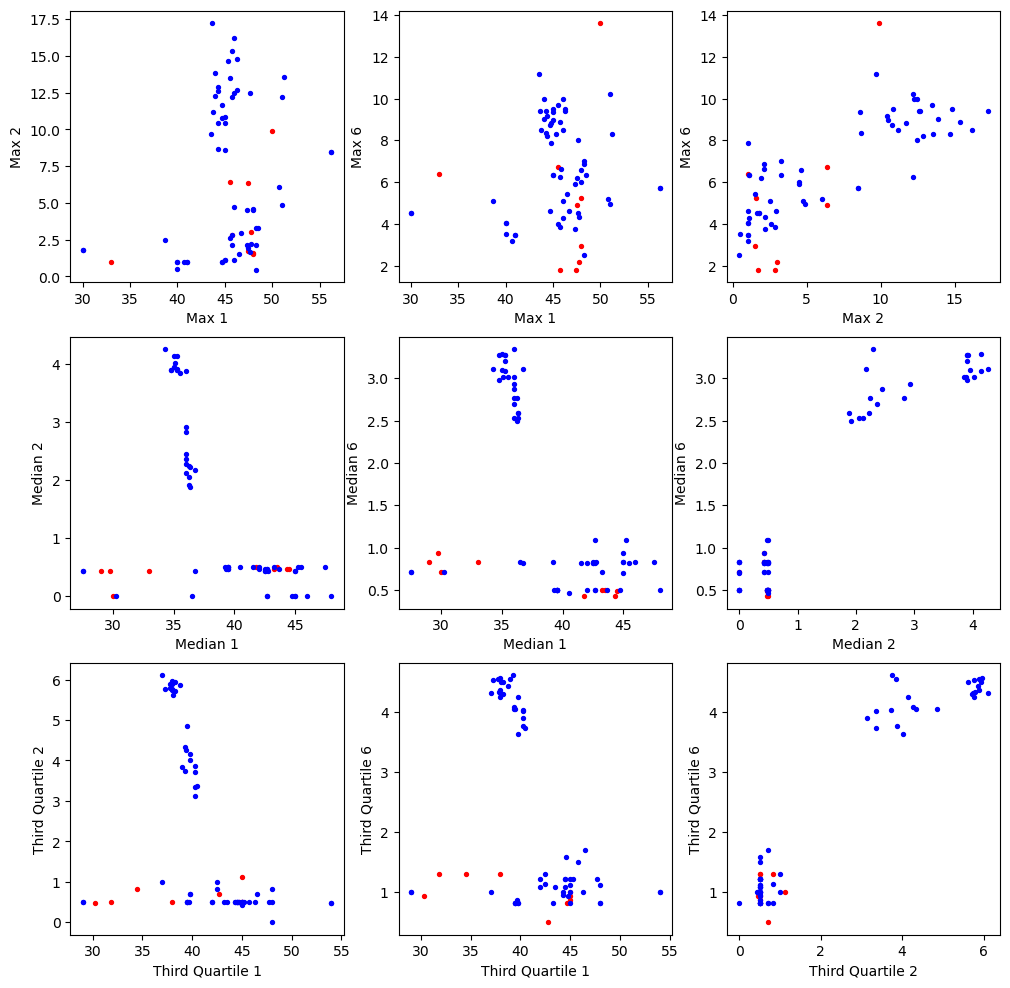

In [8]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
# Bending = Red
# Other = Blue

# Max Scatterplots -> First Row
axes[0, 0].scatter(max_1s["bending"], max_2s["bending"], c = "red", s=8)
axes[0, 0].scatter(max_1s["other"], max_2s["other"], c = "blue", s=8)
axes[0, 0].set_xlabel("Max 1")
axes[0, 0].set_ylabel("Max 2")

axes[0, 1].scatter(max_1s["bending"], max_6s["bending"], c = "red", s=8)
axes[0, 1].scatter(max_1s["other"], max_6s["other"], c = "blue", s=8)
axes[0, 1].set_xlabel("Max 1")
axes[0, 1].set_ylabel("Max 6")

axes[0, 2].scatter(max_2s["bending"], max_6s["bending"], c = "red", s=8)
axes[0, 2].scatter(max_2s["other"], max_6s["other"], c = "blue", s=8)
axes[0, 2].set_xlabel("Max 2")
axes[0, 2].set_ylabel("Max 6")

# Median Scatterplots -> Second Row
axes[1, 0].scatter(median_1s["bending"], median_2s["bending"], c = "red", s=8)
axes[1, 0].scatter(median_1s["other"], median_2s["other"], c = "blue", s=8)
axes[1, 0].set_xlabel("Median 1")
axes[1, 0].set_ylabel("Median 2")

axes[1, 1].scatter(median_1s["bending"], median_6s["bending"], c = "red", s=8)
axes[1, 1].scatter(median_1s["other"], median_6s["other"], c = "blue", s=8)
axes[1, 1].set_xlabel("Median 1")
axes[1, 1].set_ylabel("Median 6")

axes[1, 2].scatter(median_2s["bending"], median_6s["bending"], c = "red", s=8)
axes[1, 2].scatter(median_2s["other"], median_6s["other"], c = "blue", s=8)
axes[1, 2].set_xlabel("Median 2")
axes[1, 2].set_ylabel("Median 6")

# Third Quartile Scatterplots -> Third Row
axes[2, 0].scatter(thirdQ_1s["bending"], thirdQ_2s["bending"], c = "red", s=8)
axes[2, 0].scatter(thirdQ_1s["other"], thirdQ_2s["other"], c = "blue", s=8)
axes[2, 0].set_xlabel("Third Quartile 1")
axes[2, 0].set_ylabel("Third Quartile 2")

axes[2, 1].scatter(thirdQ_1s["bending"], thirdQ_6s["bending"], c = "red", s=8)
axes[2, 1].scatter(thirdQ_1s["other"], thirdQ_6s["other"], c = "blue", s=8)
axes[2, 1].set_xlabel("Third Quartile 1")
axes[2, 1].set_ylabel("Third Quartile 6")

axes[2, 2].scatter(thirdQ_2s["bending"], thirdQ_6s["bending"], c = "red", s=8)
axes[2, 2].scatter(thirdQ_2s["other"], thirdQ_6s["other"], c = "blue", s=8)
axes[2, 2].set_xlabel("Third Quartile 2")
axes[2, 2].set_ylabel("Third Quartile 6")

plt.show()

There doesn't seem to be that great of separation between bending and other.

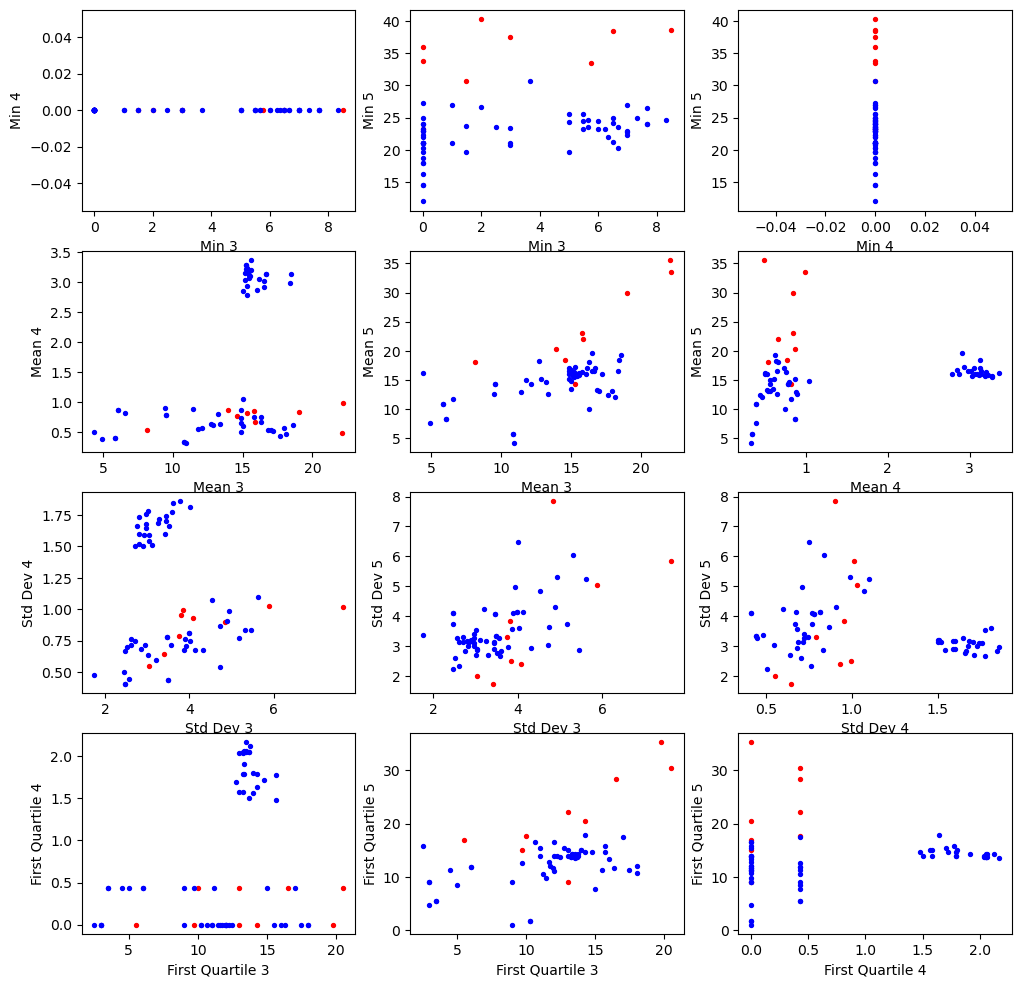

In [9]:
# Trying for the other features as well
# Min, Mean, Std Dev, FirstQ
min_1s = {"bending" : [], "other" : []}
min_2s = {"bending" : [], "other" : []}
min_6s = {"bending" : [], "other" : []}

mean_1s = {"bending" : [], "other" : []}
mean_2s = {"bending" : [], "other" : []}
mean_6s = {"bending" : [], "other" : []}

stddev_1s = {"bending" : [], "other" : []}
stddev_2s = {"bending" : [], "other" : []}
stddev_6s = {"bending" : [], "other" : []}

firstQ_1s = {"bending" : [], "other" : []}
firstQ_2s = {"bending" : [], "other" : []}
firstQ_6s = {"bending" : [], "other" : []}

for _, row in train_feat_df.iterrows(): # _ because we don't care about index, just go through entire thing
    
    file_name = row["dirfile_name"]
    
    if "bend" in file_name:
        activity = "bending"
    else:
        activity = "other"
        
    min_1s[activity].append(row["min_3"])
    min_2s[activity].append(row["min_4"])
    min_6s[activity].append(row["max_5"])

    mean_1s[activity].append(row["mean_3"])
    mean_2s[activity].append(row["mean_4"])
    mean_6s[activity].append(row["mean_5"])

    stddev_1s[activity].append(row["std_dev_3"])
    stddev_2s[activity].append(row["std_dev_4"])
    stddev_6s[activity].append(row["std_dev_5"])

    firstQ_1s[activity].append(row["first_quart_3"])
    firstQ_2s[activity].append(row["first_quart_4"])
    firstQ_6s[activity].append(row["first_quart_5"])

fig, axes = plt.subplots(4, 3, figsize = (12, 12))
# Bending = Red
# Other = Blue

# Min Scatterplots -> First Row
axes[0, 0].scatter(min_1s["bending"], min_2s["bending"], c = "red", s=8)
axes[0, 0].scatter(min_1s["other"], min_2s["other"], c = "blue", s=8)
axes[0, 0].set_xlabel("Min 3")
axes[0, 0].set_ylabel("Min 4")

axes[0, 1].scatter(min_1s["bending"], min_6s["bending"], c = "red", s=8)
axes[0, 1].scatter(min_1s["other"], min_6s["other"], c = "blue", s=8)
axes[0, 1].set_xlabel("Min 3")
axes[0, 1].set_ylabel("Min 5")

axes[0, 2].scatter(min_2s["bending"], min_6s["bending"], c = "red", s=8)
axes[0, 2].scatter(min_2s["other"], min_6s["other"], c = "blue", s=8)
axes[0, 2].set_xlabel("Min 4")
axes[0, 2].set_ylabel("Min 5")

# Mean Scatterplots -> Second Row
axes[1, 0].scatter(mean_1s["bending"], mean_2s["bending"], c = "red", s=8)
axes[1, 0].scatter(mean_1s["other"], mean_2s["other"], c = "blue", s=8)
axes[1, 0].set_xlabel("Mean 3")
axes[1, 0].set_ylabel("Mean 4")

axes[1, 1].scatter(mean_1s["bending"], mean_6s["bending"], c = "red", s=8)
axes[1, 1].scatter(mean_1s["other"], mean_6s["other"], c = "blue", s=8)
axes[1, 1].set_xlabel("Mean 3")
axes[1, 1].set_ylabel("Mean 5")

axes[1, 2].scatter(mean_2s["bending"], mean_6s["bending"], c = "red", s=8)
axes[1, 2].scatter(mean_2s["other"], mean_6s["other"], c = "blue", s=8)
axes[1, 2].set_xlabel("Mean 4")
axes[1, 2].set_ylabel("Mean 5")

# Std Dev Scatterplots -> Third Row
axes[2, 0].scatter(stddev_1s["bending"], stddev_2s["bending"], c = "red", s=8)
axes[2, 0].scatter(stddev_1s["other"], stddev_2s["other"], c = "blue", s=8)
axes[2, 0].set_xlabel("Std Dev 3")
axes[2, 0].set_ylabel("Std Dev 4")

axes[2, 1].scatter(stddev_1s["bending"], stddev_6s["bending"], c = "red", s=8)
axes[2, 1].scatter(stddev_1s["other"], stddev_6s["other"], c = "blue", s=8)
axes[2, 1].set_xlabel("Std Dev 3")
axes[2, 1].set_ylabel("Std Dev 5")

axes[2, 2].scatter(stddev_2s["bending"], stddev_6s["bending"], c = "red", s=8)
axes[2, 2].scatter(stddev_2s["other"], stddev_6s["other"], c = "blue", s=8)
axes[2, 2].set_xlabel("Std Dev 4")
axes[2, 2].set_ylabel("Std Dev 5")

# First Quartile Scatterplots -> Fourth Row
axes[3, 0].scatter(firstQ_1s["bending"], firstQ_2s["bending"], c = "red", s=8)
axes[3, 0].scatter(firstQ_1s["other"], firstQ_2s["other"], c = "blue", s=8)
axes[3, 0].set_xlabel("First Quartile 3")
axes[3, 0].set_ylabel("First Quartile 4")

axes[3, 1].scatter(firstQ_1s["bending"], firstQ_6s["bending"], c = "red", s=8)
axes[3, 1].scatter(firstQ_1s["other"], firstQ_6s["other"], c = "blue", s=8)
axes[3, 1].set_xlabel("First Quartile 3")
axes[3, 1].set_ylabel("First Quartile 5")

axes[3, 2].scatter(firstQ_2s["bending"], firstQ_6s["bending"], c = "red", s=8)
axes[3, 2].scatter(firstQ_2s["other"], firstQ_6s["other"], c = "blue", s=8)
axes[3, 2].set_xlabel("First Quartile 4")
axes[3, 2].set_ylabel("First Quartile 5")

plt.show()
    

Something to Note:
- For min, mean, std dev, and first quartile for 1, 2, and 6 the separation isn't great either.
- HOWEVER, when I changed out 1, 2, and 6 for 3, 4, and 5 there is clearly better separation (as shown above).
- - This happens for max, median, and third quartile as well (the three features I chose), but I left those scatterplots as is since the question asks for 1, 2, and 6, but I just want to point out that 3, 4, and 5 gives better separation across ALL the features.

Question 2.a.ii
- Break each time series in your training set into two (approximately) equal length time series
- Now instead of 6 time series for each of the training instances, you have 12 time series for each training instance
- Repeat the experiment in 2.a.i (ie: depict scatter plots of the features extracted from both parts of the time series 1, 2, and 6)
- Do you see any considerable difference in the results with those of 2.a.i?

In [10]:
# splitting all time series into halves 
# training_dfs = {} -> {bending2_dataset4 : df, walking_dataset1 : df, ...etc}

training_dfs_halves = {} # key = dirfilename, value = df

for ts in training_dfs:
    curr_ts = training_dfs[ts] # grabbing one time series at a time

    the_mid = len(curr_ts) // 2 # midpoint to split on

    first_half_ts = curr_ts.iloc[:the_mid]
    second_half_ts = curr_ts.iloc[the_mid:]

    new_name_1 = ts + "_half1" # bending2_dataset4_half1
    new_name_2 = ts + "_half2"

    training_dfs_halves[new_name_1] = first_half_ts
    training_dfs_halves[new_name_2] = second_half_ts

In [11]:
training_features_halves = []
# 138 rows x 42 columns

for dirfile3, its_df3 in training_dfs_halves.items():
    c_instance = {}
    c_instance["dirfile_name"] = dirfile3 # to keep track of where the numbers are coming from

    for k, c_column in enumerate(columns_six, start=1):
        c_instance[f"min_{k}"] = its_df3[c_column].min()
        c_instance[f"max_{k}"] = its_df3[c_column].max()
        c_instance[f"mean_{k}"] = its_df3[c_column].mean()
        c_instance[f"median_{k}"] = its_df3[c_column].median()
        c_instance[f"std_dev_{k}"] = its_df3[c_column].std()
        c_instance[f"first_quart_{k}"] = its_df3[c_column].quantile(0.25)
        c_instance[f"third_quart_{k}"] = its_df3[c_column].quantile(0.75)

    training_features_halves.append(c_instance)

train_feat_halves_df = pd.DataFrame(training_features_halves)

In [12]:
max_1s_break = {"bending" : [], "other" : []}
max_2s_break = {"bending" : [], "other" : []}
max_6s_break = {"bending" : [], "other" : []}

median_1s_break = {"bending" : [], "other" : []}
median_2s_break = {"bending" : [], "other" : []}
median_6s_break = {"bending" : [], "other" : []}

thirdQ_1s_break = {"bending" : [], "other" : []}
thirdQ_2s_break = {"bending" : [], "other" : []}
thirdQ_6s_break = {"bending" : [], "other" : []}

for _, row in train_feat_halves_df.iterrows():
    
    file_name = row["dirfile_name"]
    
    if "bend" in file_name:
        activity = "bending"
    else:
        activity = "other"
        
    max_1s_break[activity].append(row["max_1"])
    max_2s_break[activity].append(row["max_2"])
    max_6s_break[activity].append(row["max_6"])

    median_1s_break[activity].append(row["median_1"])
    median_2s_break[activity].append(row["median_2"])
    median_6s_break[activity].append(row["median_6"])

    thirdQ_1s_break[activity].append(row["third_quart_1"])
    thirdQ_2s_break[activity].append(row["third_quart_2"])
    thirdQ_6s_break[activity].append(row["third_quart_6"])


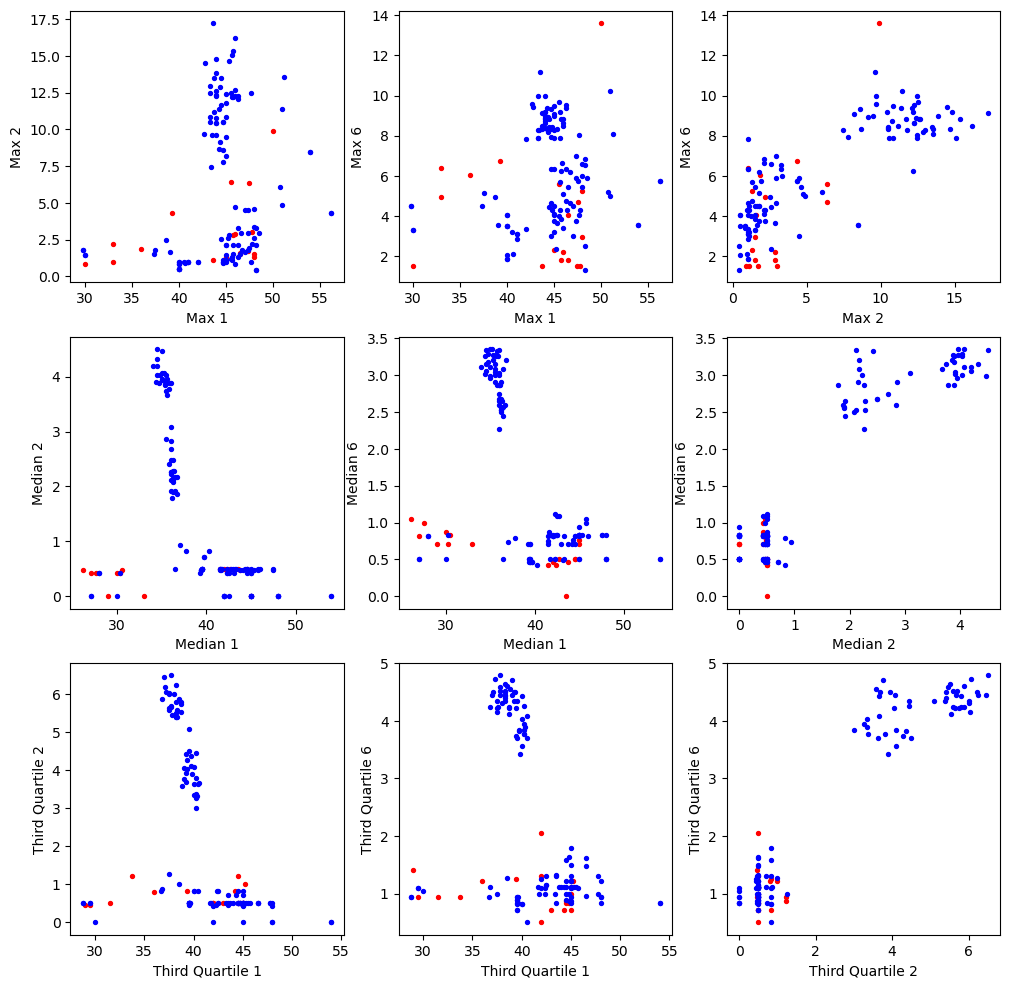

In [13]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
# Bending = Red
# Other = Blue

# Max Scatterplots -> First Row
axes[0, 0].scatter(max_1s_break["bending"], max_2s_break["bending"], c = "red", s=8)
axes[0, 0].scatter(max_1s_break["other"], max_2s_break["other"], c = "blue", s=8)
axes[0, 0].set_xlabel("Max 1")
axes[0, 0].set_ylabel("Max 2")

axes[0, 1].scatter(max_1s_break["bending"], max_6s_break["bending"], c = "red", s=8)
axes[0, 1].scatter(max_1s_break["other"], max_6s_break["other"], c = "blue", s=8)
axes[0, 1].set_xlabel("Max 1")
axes[0, 1].set_ylabel("Max 6")

axes[0, 2].scatter(max_2s_break["bending"], max_6s_break["bending"], c = "red", s=8)
axes[0, 2].scatter(max_2s_break["other"], max_6s_break["other"], c = "blue", s=8)
axes[0, 2].set_xlabel("Max 2")
axes[0, 2].set_ylabel("Max 6")

# Median Scatterplots -> Second Row
axes[1, 0].scatter(median_1s_break["bending"], median_2s_break["bending"], c = "red", s=8)
axes[1, 0].scatter(median_1s_break["other"], median_2s_break["other"], c = "blue", s=8)
axes[1, 0].set_xlabel("Median 1")
axes[1, 0].set_ylabel("Median 2")

axes[1, 1].scatter(median_1s_break["bending"], median_6s_break["bending"], c = "red", s=8)
axes[1, 1].scatter(median_1s_break["other"], median_6s_break["other"], c = "blue", s=8)
axes[1, 1].set_xlabel("Median 1")
axes[1, 1].set_ylabel("Median 6")

axes[1, 2].scatter(median_2s_break["bending"], median_6s_break["bending"], c = "red", s=8)
axes[1, 2].scatter(median_2s_break["other"], median_6s_break["other"], c = "blue", s=8)
axes[1, 2].set_xlabel("Median 2")
axes[1, 2].set_ylabel("Median 6")

# Third Quartile Scatterplots -> Third Row
axes[2, 0].scatter(thirdQ_1s_break["bending"], thirdQ_2s_break["bending"], c = "red", s=8)
axes[2, 0].scatter(thirdQ_1s_break["other"], thirdQ_2s_break["other"], c = "blue", s=8)
axes[2, 0].set_xlabel("Third Quartile 1")
axes[2, 0].set_ylabel("Third Quartile 2")

axes[2, 1].scatter(thirdQ_1s_break["bending"], thirdQ_6s_break["bending"], c = "red", s=8)
axes[2, 1].scatter(thirdQ_1s_break["other"], thirdQ_6s_break["other"], c = "blue", s=8)
axes[2, 1].set_xlabel("Third Quartile 1")
axes[2, 1].set_ylabel("Third Quartile 6")

axes[2, 2].scatter(thirdQ_2s_break["bending"], thirdQ_6s_break["bending"], c = "red", s=8)
axes[2, 2].scatter(thirdQ_2s_break["other"], thirdQ_6s_break["other"], c = "blue", s=8)
axes[2, 2].set_xlabel("Third Quartile 2")
axes[2, 2].set_ylabel("Third Quartile 6")

plt.show()

- I do not see a considerable difference between these scatterplots and the 2.a.i scatterplots
- I checked 3, 4, and 5 again and they still have better separation than 1, 2, and 6. I did not check the other 4 features this time.

Question 2.a.iii
- Break each time series in your training set into l -> {1, 2, ..., 20} time series of approximately equal length and use logistic regression to solve the binary classifciation problem, using time-domain features
- - (If you encounter instability of the logreg problem because of linearly separable classes, modify the Max-Iter parameter in logreg to stop the alg immaturely and prevent instability)
- Remember that breaking each of the time series does not change the number of instances, it only changes the number of features for each instance
- Calculate the p-values for your logreg parameters in each model corresponding to each value of l and refit a logistic regression model using your pruned set of features
- - (R calculates the p-values for logreg automatically. One of way of calculating them in Python is to call R within Python. There are other ways to obtain the p-values as well)
- Alternatively, you can use backward selecting using sklearn.feature.selection or glm in R
- Use 5-fold cross validation to determine the best value of the pair (l, p), where p is the number of features used in recursive feature elimination
- Explain what the right way and the wrong way are to perform cross-validation in this problem (use the right way!)
- - (Interesting problem in which the # of features changes depending on the value of the parameter l that is selected via cross validation)
- Also, you may encounter the problem of class imbalance, which may make some of your folds not having any instances of the rare class -> in such a case, use stratified cross validation (research this if needed)
- Example given of Python's Recursive Feature Elimination

!!!!!!!!!!
ANSWER for CROSS VALIDATION -> Right and Wrong Way (based on notes from class):
- Right Way:
- - split into folds (5-fold: 4 train, 1 validation)
  - THEN do feature selection using the training folds
  - fit log reg on the features selected, evalaute on validation
  - repeat for 5 folds
- Wrong Way:
- - Use whole training set to select features, fix the features
  - Cross validate on just the log reg model
  - !!! Test fold has seen feature selection -> data leakage
- We do not use the models created by cross validation, it is for model selection only
- Will get best L and P from cross validation, will need to make new model after cross validation with best L and P

In [14]:
# FIRST: just splitting all the time series files into L splits, saving in a dictionary
def splitting_time_series(df, l_val):
    splits = np.array_split(df, l_val) # split into splits using np.array_split
    df_splits = []
    for split in splits:
        # converting back to dataframes so I can column index in split_td_features
        split_df = pd.DataFrame(split, columns=df.columns)
        df_splits.append(split_df)

    return df_splits

In [15]:
L_splits = {} # will look like:
                            #  {1 : {bending1_dataset1 : [1df], ...}, 
                            #   2 : {bending1_dataset1 : [2ds], ...}, 
                            #   ..., 
                            #   20: {bending1_dataset1 : [20dfs], ...} }
              
              # key OUTER DICT: L number
              # value OUTER DICT: dictionary of each file with L splits

              # key INNER DICT: name of file (bending1_dataset2)
              # value INNER DICT: list of L dfs split from file, returned from splitting_time_series

for L in range(1, 21): # 1 -> 20
    L_splits[L] = {}
    for file_name, df in training_dfs.items():
        L_splits[L][file_name] = splitting_time_series(df, L)
    

In [16]:
def split_td_features(df):
    td_features = []
    for c in columns_six:
        td_features.append(df[c].min())
        td_features.append(df[c].max())
        td_features.append(df[c].mean())
        td_features.append(df[c].median())
        td_features.append(df[c].std())
        td_features.append(df[c].quantile(0.25))
        td_features.append(df[c].quantile(0.75))
    return td_features

In [17]:
# Extracting Time Domain features for each instance segment
# Like: min of avg_rss12 of split_1 for L = 2, etc.
# columns_six -> avg_rss12, etc.

L_features = {} 
# Basically same format as L_splits: instead of list of df splits as inner dict value, it is list of td features

for L in L_splits:
    L_features[L] = {}

    for file_name in L_splits[L]:
        the_splits = L_splits[L][file_name]
        all_split_features = []
        for sdf in the_splits:
            one_split_features = split_td_features(sdf)
            all_split_features.extend(one_split_features)
        L_features[L][file_name] = all_split_features

In [18]:
# inputs for log reg
input_x = {} # list of features for particular L from L_features : FEATURES
             # looks like: {1 : [69 rows with 42 features], 2 : [69 rows with 84 features], etc...}
input_y = {} # 1 if bending, 0 if other : LABELS

for L in L_features:
    the_features = []
    the_labels = []
    for file_name in L_features[L]:
        the_features.append(L_features[L][file_name])
        if "bend" in file_name:
            the_labels.append(1)
        else:
            the_labels.append(0)
    
    input_x[L] = the_features
    input_y[L] = the_labels


In [19]:
# split into folds (4 train, 1 validation)
# feature select using training folds
# fit log reg on selected features, evaluate on validation
# repeat for 5 folds

# doing log reg + RFE

cross_val_strat = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
# 5 folds
# shuffle each class's samples before splitting into batches
# random_state = 1 -> cross val results identical across runs, reproducible, no info leakage

best_cross_val_score = 0
best_L = None
best_P = None

for L in range(1, 21):
    input_x_L = input_x[L]
    input_y_L = input_y[L]

    input_x_arr = np.array(input_x_L)
    input_y_arr = np.array(input_y_L)
    # need as arrays to do train_idx / test_idx

    end_range = len(input_x[L][0]) + 1 # get range of features that adapts to each num of features
    for P in range(10, end_range, 25):
        cv_fold_scores = [] # saving cross val scores
        print(f"L: {L}, P: {P}")

        # manually looping through splits (was getting issues doing it the automated way and just switched to doing manual)
        for train_idx, test_idx in cross_val_strat.split(input_x_arr, input_y_arr):
            # 1 -> SPLITTING first 
            # training
            X_train = input_x_arr[train_idx]
            Y_train = input_y_arr[train_idx]
            # testing
            X_test = input_x_arr[test_idx]
            Y_test = input_y_arr[test_idx]

            pre_logreg_model = LogisticRegression(max_iter=1000)

            rfe = RFE(estimator = pre_logreg_model, n_features_to_select=P)

            # 2 -> FEATURE SELECT on TRAINING
            # fitting rfe to training folds
            # selects the features
            rfe_training = rfe.fit_transform(X_train, Y_train)
            # validation fold
            rfe_testing = rfe.transform(X_test)

            # 3 -> FIT LOG REG on SELECTED TRAIN FEATURES
            # train log reg on selected features from rfe
            post_logreg_model = LogisticRegression(max_iter=1000)
            post_logreg_model.fit(rfe_training, Y_train)

            # 4 -> PREDICT on VALIDATION FOLD
            class_prediction = post_logreg_model.predict(rfe_testing)

            # checking cross val accuracy 
            cv_acc = accuracy_score(Y_test, class_prediction)
            cv_fold_scores.append(cv_acc)

            # 5 -> REPEAT for 5 folds

        mean_cv_score = np.mean(cv_fold_scores)
        # ^ average of the 5 scores across the 5 folds 
        # average for this particular L and P

        if mean_cv_score > best_cross_val_score:
            best_cross_val_score = mean_cv_score
            best_L = L
            best_P = P
# printing out L and P to keep track of where the process is
        

L: 1, P: 10
L: 1, P: 35
L: 2, P: 10
L: 2, P: 35
L: 2, P: 60
L: 3, P: 10
L: 3, P: 35
L: 3, P: 60
L: 3, P: 85
L: 3, P: 110
L: 4, P: 10
L: 4, P: 35
L: 4, P: 60
L: 4, P: 85
L: 4, P: 110
L: 4, P: 135
L: 4, P: 160
L: 5, P: 10
L: 5, P: 35
L: 5, P: 60
L: 5, P: 85
L: 5, P: 110
L: 5, P: 135
L: 5, P: 160
L: 5, P: 185
L: 5, P: 210
L: 6, P: 10
L: 6, P: 35
L: 6, P: 60
L: 6, P: 85
L: 6, P: 110
L: 6, P: 135
L: 6, P: 160
L: 6, P: 185
L: 6, P: 210
L: 6, P: 235
L: 7, P: 10
L: 7, P: 35
L: 7, P: 60
L: 7, P: 85
L: 7, P: 110
L: 7, P: 135
L: 7, P: 160
L: 7, P: 185
L: 7, P: 210
L: 7, P: 235
L: 7, P: 260
L: 7, P: 285
L: 8, P: 10
L: 8, P: 35
L: 8, P: 60
L: 8, P: 85
L: 8, P: 110
L: 8, P: 135
L: 8, P: 160
L: 8, P: 185
L: 8, P: 210
L: 8, P: 235
L: 8, P: 260
L: 8, P: 285
L: 8, P: 310
L: 8, P: 335
L: 9, P: 10
L: 9, P: 35
L: 9, P: 60
L: 9, P: 85
L: 9, P: 110
L: 9, P: 135
L: 9, P: 160
L: 9, P: 185
L: 9, P: 210
L: 9, P: 235
L: 9, P: 260
L: 9, P: 285
L: 9, P: 310
L: 9, P: 335
L: 9, P: 360
L: 10, P: 10
L: 10, P: 35
L: 10,

IMPORTANT !!!!!!!!!!!!!!!!
- I had to reduce the amount of P values I was checking above since it was taking a very very very long time, even what's shown above took a very long time

In [20]:
print(f"Best Cross Validation Score: {best_cross_val_score}")
print(f"Best L: {best_L}")
print(f"Best P: {best_P}")

Best Cross Validation Score: 0.9857142857142858
Best L: 1
Best P: 10


In [55]:
# final model with best L and P
input_x_best = np.array(input_x[best_L])
input_y_best = np.array(input_y[best_L])

pre_logreg_model_best = LogisticRegression(max_iter=1000, C=1e20)
best_rfe = RFE(estimator = pre_logreg_model_best, n_features_to_select = best_P)

best_selected_features = best_rfe.fit_transform(input_x_best, input_y_best)

post_logreg_model_best = LogisticRegression(max_iter=1000, C=1e20)
post_logreg_model_best.fit(best_selected_features, input_y_best)

print(best_rfe.support_)

[False False  True False False False  True False  True False False False
 False False False False False  True False False False False False False
 False False False False  True  True  True False False  True  True False
  True False False False False False]


In [56]:
td_feats = ["min", "max", "mean", "median", "std", "Q1", "Q3"]
og_col_feature_names = []

for c in columns_six:
    for td_feat in td_feats:
        og_col_feature_names.append(f"{td_feat}_{c}")

rfe_selected_features = []
for i in range(len(og_col_feature_names)):
    if best_rfe.support_[i]:
        rfe_selected_features.append(og_col_feature_names[i])

print("The best features rfe picked out are:\n")
for feat in rfe_selected_features:
    print(feat)

The best features rfe picked out are:

mean_avg_rss12
Q3_avg_rss12
max_var_rss12
median_avg_rss13
min_avg_rss23
max_avg_rss23
mean_avg_rss23
Q1_avg_rss23
Q3_avg_rss23
max_var_rss23


Question 2.a.iv
- Report the confusion matrix and show the ROC and AUC for your classifier on train data
- Report the parameters of your logistic regression Beta_is as well as the p-values associated with them

1. Confusion Matrix
2. ROC for classifier on train data
3. AUC for classifier on train data
4. Parameters of log reg Beta_is
5. - p-values associated with ^

In [57]:
# make predictions for cm
selected_feats_train = best_rfe.transform(input_x_best)
predictions = post_logreg_model_best.predict(selected_feats_train)

#confusion matrix
conf_mat = confusion_matrix(input_y_best, predictions)
print(conf_mat)
    # output: 60 TN, 9 TP, 0 FP, 0 FN ... possible overfitting, but cv score was high

[[60  0]
 [ 0  9]]


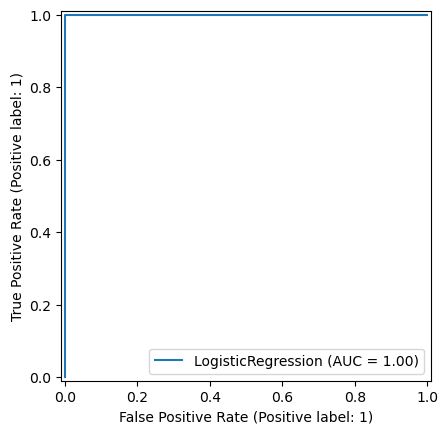

In [58]:
# ROC and AUC
RocCurveDisplay.from_estimator(post_logreg_model_best, selected_feats_train, input_y_best)

- AUC showing as = 1. Again, a little suspicious, but cv score was high and cm showed 100% accuracy
- ROC curve shows same thing, shows that classifier separates the classes perfectly

In [59]:
# Parameters of leg reg Beta_is
intercept = post_logreg_model_best.intercept_
print(f"Intercept: {intercept}")

coeffs = post_logreg_model_best.coef_
print(f"Coefficients:")
for i in range (0, 10):
    print(f"\t{rfe_selected_features[i]} -> {coeffs[0][i]}")

Intercept: [-0.04332457]
Coefficients:
	mean_avg_rss12 -> -0.888990172984807
	Q3_avg_rss12 -> -1.1688037457453397
	max_var_rss12 -> -0.7783987432304085
	median_avg_rss13 -> -0.8029200067439325
	min_avg_rss23 -> 1.4888107340155678
	max_avg_rss23 -> 1.7689283714899755
	mean_avg_rss23 -> 0.7982486292236897
	Q1_avg_rss23 -> 0.7910711688344286
	Q3_avg_rss23 -> 0.5428966326644826
	max_var_rss23 -> -0.7387813833459939


In [61]:
int_const = sm.add_constant(selected_feats_train)
sm_logreg_model = sm.Logit(input_y_best, int_const)
# sm_logreg_results = sm_logreg_model.fit(maxiter=1000)
# p_values = sm_logreg_results.pvalues
# print(results.summary())

IMPORTANT !!!!!!!!!
- Because I get 100% accuracy, I get an error when un-commenting out the last three lines above
- The error is because I get a matrix that is singular due to the accuracy
- Since the model completely separates the classes on the training data, the p-values are unstable 

Question 2.a.v
- Test the classifier on the test set
- Remember to break the time series in your test set into the same number of time series into which you broke your training set
- Remember that the classifier has to be tested using the features extracted from the test set
- Compare the accuracy on the test set with the cross-validation accuracy you obtained previously

In [78]:
# Breaking test set into Best L splits
# best_L, best_P, testing_dfs

L_test_splits = {}
L_test_splits[best_L] = {}
for file_name, df in testing_dfs.items():
    L_test_splits[best_L][file_name] = splitting_time_series(df, best_L)

L_test_features = {}
L_test_features[best_L] = {}
for file_name in L_test_splits[best_L]:
    the_splits = L_test_splits[best_L][file_name]
    all_split_features = []
    for sdf in the_splits:
        one_split_features = split_td_features(sdf)
        all_split_features.extend(one_split_features)
    L_test_features[best_L][file_name] = all_split_features

testing_x = []
testing_y = []

for file_name in L_test_features[best_L]:
    testing_x.append(L_test_features[best_L][file_name])
    if "bend" in file_name:
        testing_y.append(1)
    else:
        testing_y.append(0)

testing_x_arr = np.array(testing_x)
testing_y_arr = np.array(testing_y)

testing_selected_features = best_rfe.transform(testing_x_arr)
testing_predictions = post_logreg_model_best.predict(testing_selected_features)

testing_acc = accuracy_score(testing_y_arr, testing_predictions)
print(f"Testing Acc Score: {testing_acc}")
print(f"Cross Val Score: {best_cross_val_score}")

Testing Acc Score: 1.0
Cross Val Score: 0.9857142857142858


- Cross validation can give more of a realistic look at performance since it validates over multiple different validation sets while the testing accuracy only tests over that one testing slice, so the cross validation score being slightly smaller makes sense
- Since the drop is so small though it may also just be noise

Question 2.a.vi
- Do your classes seem to be well-separated to cause instability in calculating logistic regression parameters?

MY ANSWER:
- Yes, my results show completel separation, with the confusion matrix showing no False Positives and no False Negatives, my AUC = 1, and my test accuracy = 1 as well. I could not obtain p-values due to this

Question 2.a.vii
- From the confusion matrices you obtained, do you see imbalanced classes?
- If yes, build a logistic regression model based on case-control sampling and adjust its parameters
- Report the confusion matric, ROC, and AUC of the model

MY ANSWER:
- Yes, I do see imbalanced classes. In my confusion matrix I got 60 TN (non-bending class) and 9 TP (bending class), so it leans way more towards the non-bending class. 

In [86]:
# building log reg model based on case-control sampling and adjusting intercept
# x -> selected_feats_train
# y -> input_y_best

# bending
x_case = selected_feats_train[input_y_best == 1]
y_case = input_y_best[input_y_best == 1]

# non-bending
x_control = selected_feats_train[input_y_best == 0]
y_control = input_y_best[input_y_best == 0]

cc_xs = np.concatenate([x_case, x_control])
cc_ys = np.concatenate([y_case, y_control])

rus = RandomUnderSampler(random_state = 1)

x_resamp, y_resamp = rus.fit_resample(cc_xs, cc_ys)

resamp_logreg = LogisticRegression(max_iter=1000, C=1e20)
resamp_logreg.fit(x_resamp, y_resamp)

r = 0.5
p = np.mean(input_y_best)

beta_0_resampled = resamp_logreg.intercept_[0]
offset = np.log(r / (1 - r)) - np.log(p / (1 - p))
adjusted_intercept = beta_0_resampled - offset
resamp_logreg.intercept_[0] = adjusted_intercept
probabilities = resamp_logreg.predict_proba(testing_selected_features)[:, 1]

[[15  0]
 [ 0  4]]


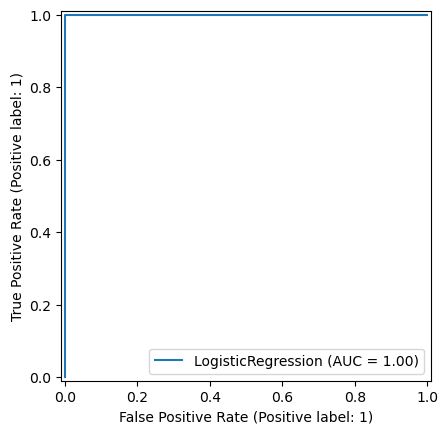

In [87]:
# reporting confusion matric, ROC, and AUC
cc_predictions = resamp_logreg.predict(testing_selected_features)
cc_cm = confusion_matrix(testing_y_arr, cc_predictions)
print(cc_cm)

RocCurveDisplay.from_estimator(resamp_logreg, testing_selected_features, testing_y_arr)

- I still get perfect separation of classes even with the balanced classes

Question 2.b.i
- Repeat 2.a.iii (5-fold cross val) using L1-penalized logistic regression (ie: instead of using p-values for variable selection, use L1 regularization)
- Note that in this problem, you have to cross-validate for BOTH: L (# of time series into which you break ur instances) AND lambda (weight of L1 penalty in your log reg objective function -> or C, the budget)
- Packages usually perform cross-validation for lambda automatically
- - For L1-penalized log reg, may want to use normalized/standardized features
  - Using the package Liblinear is strongly recommended

- Cross Val using L1-penalized logreg (instead of p-values)
- - Cross Val for L and Lambda
  - Use standardized features
  - Use Liblinear

In [96]:
# penalized L1 log reg
# using automated cv this time

l1_best_score = 0
l1_best_L = None
l1_best_C = None

l1_best_model = None
l1_best_scaler = None

for L in range(1, 21):
    l1_x = input_x[L]
    l1_y = input_y[L]

    l1_x_arr = np.array(input_x_L)
    l1_y_arr = np.array(input_y_L)

    scaler = StandardScaler()
    scaled_l1_x = scaler.fit_transform(l1_x_arr)

    l1_logreg_model = LogisticRegressionCV(max_iter=1000, cv=5, l1_ratios=(1.0,), solver="liblinear", use_legacy_attributes=False)
    l1_logreg_model.fit(scaled_l1_x, l1_y_arr)

    # .scores_ gives matrix of scores across the 5 folds
    # doing mean so it averages score of each fold, THEN picking best, since each score in a fold is a diff model
    cv_scores = l1_logreg_model.scores_[1]
    cv_scores_means = np.mean(cv_scores)
    best_cv_score = cv_scores_means.max()
    optimal_C = l1_logreg_model.C_

    if best_cv_score > l1_best_score:
        l1_best_score = best_cv_score
        l1_best_L = L
        l1_best_C = optimal_C
        l1_best_model = l1_logreg_model
        l1_best_scaler = scaler

print(f"Best CV Score: {l1_best_score}")
print(f"Best L: {l1_best_L}")
print(f"Best C: {l1_best_C}")


Best CV Score: 0.9428571428571428
Best L: 5
Best C: 166.81005372000558


Question 2.b.ii
- Compare the L1-penalized with variable selection using p-values
- Which one performs better?
- Which one is easier to implement?

MY ANSWER:
- The variable selection using p-values way acheived a CV score of 0.9857142857142858
- The L1 penalized way acheived a CV score of 0.9428571428571428
- The variable selection way did better performance wise
- The L1 penalized way was MUCH easier to implement though since LogisticRegressionCV did the cross validation automatically